<a href="https://colab.research.google.com/github/jintubhuyan-2000/ForestFireCarbonRecovery/blob/main/4_2_Vegetation_Response_NDVI_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SECTION 4.2: NDVI TIME SERIES ANALYSIS
Maharashtra Forest Fires - 2021

4.2.1 PRE-FIRE VEGETATION CONDITION

Pre-fire (2020):
  Mean: 0.578 ± 0.113
  Range: 0.234 - 0.695
  CV: 19.5%

Fire Year (2021):
  Mean: 0.499 ± 0.083
  Range: 0.298 - 0.616
  CV: 16.7%

Post-fire 1 (2022):
  Mean: 0.552 ± 0.100
  Range: 0.296 - 0.666
  CV: 18.1%

Post-fire 2 (2023):
  Mean: 0.559 ± 0.106
  Range: 0.228 - 0.670
  CV: 19.1%

4.2.2 IMMEDIATE FIRE IMPACT

NDVI Reduction:
  Mean loss: 0.080 ± 0.072
  Maximum loss: 0.226
  Percentage reduction: 13.8%
  Spatial heterogeneity (CV): 89.8%

4.2.3 POST-FIRE RECOVERY TRAJECTORY

Phase 1: Rapid Initial Recovery (2022)
  NDVI: 0.552 ± 0.100
  Recovery: 97.1% ± 13.8%

Phase 2: Slower Secondary Recovery (2023)
  NDVI: 0.559 ± 0.106
  Recovery: 97.0% ± 8.1%

STATISTICAL SIGNIFICANCE

Paired T-test Results:
  Pre-fire vs Fire Year: t = 4.311, p = 0.0007
  Pre-fire vs 2022: t = 1.383, p = 0.1884
  Pre-fire vs 2023: t = 1.520, p = 0.1508
  Fire Year vs 2023: t = -5.

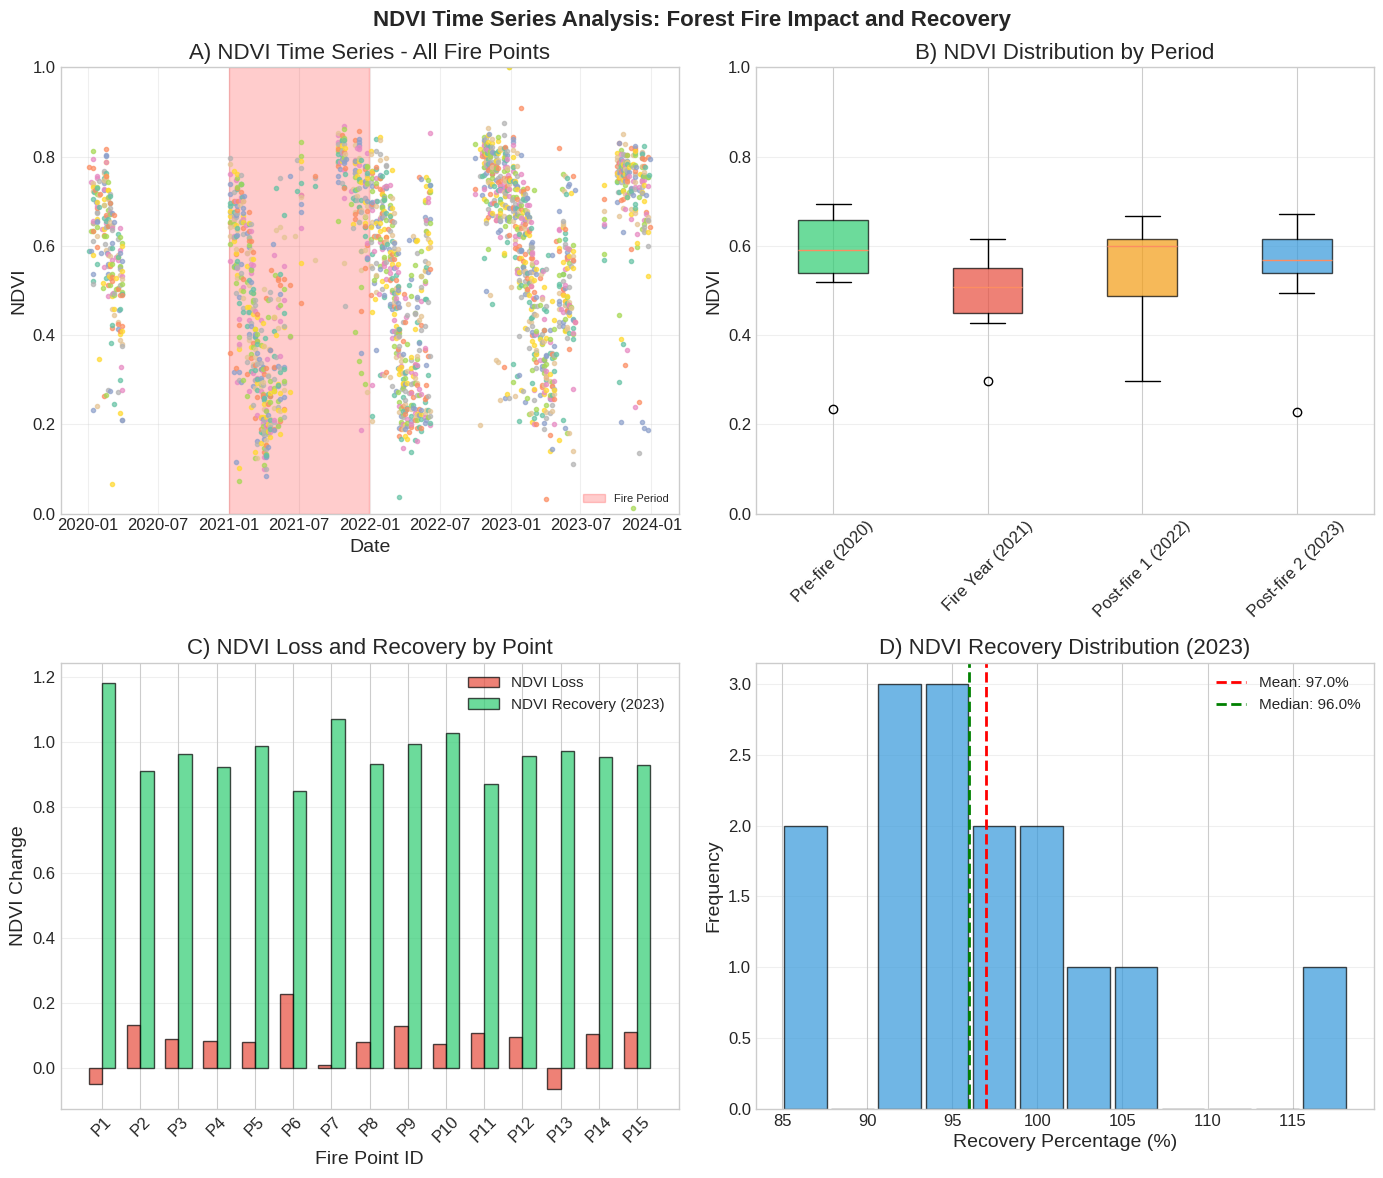


✅ Figure 2 saved: Figure_2_NDVI_Analysis.png


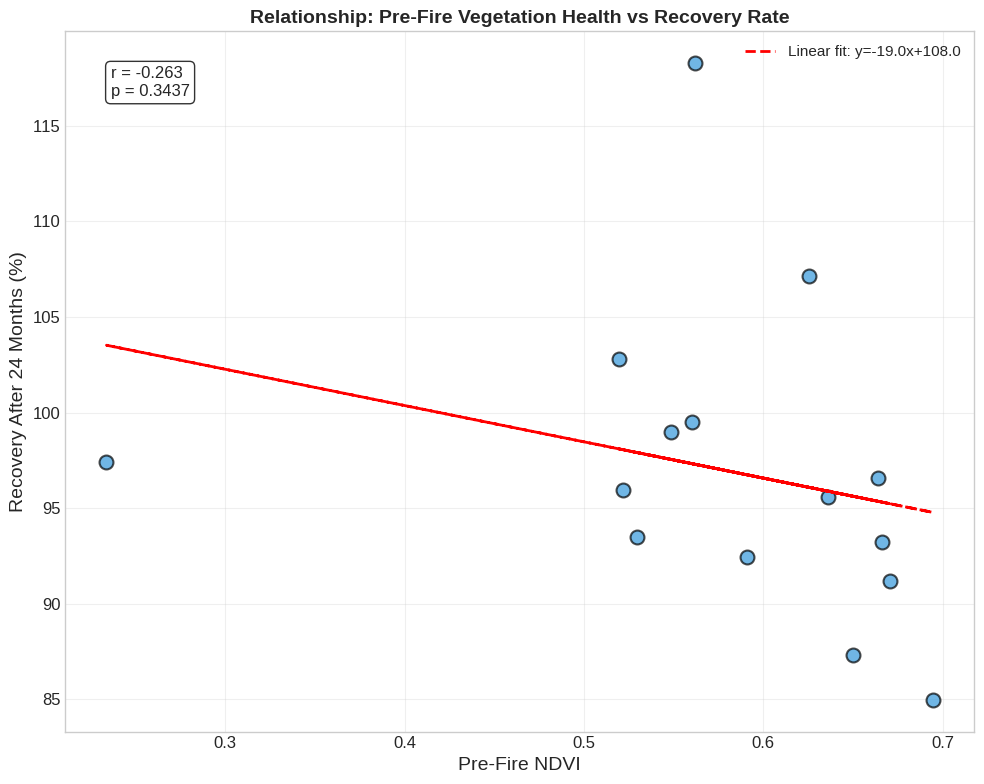

✅ Correlation plot saved: Figure_2_Supplement_Correlation.png

✅ Summary saved to: /content/drive/MyDrive/EarthEngine_Publication_Exports/Section_4.2_NDVI_Analysis_Summary.txt

VALUES TO COPY INTO MANUSCRIPT

[INSERT THESE VALUES INTO SECTION 4.2.1]
  NDVI ranged from 0.234 to 0.695
  Mean NDVI: 0.578 ± 0.113

[INSERT THESE VALUES INTO SECTION 4.2.2]
  Fire year NDVI: 0.499 ± 0.083
  13.8% reduction
  Maximum NDVI loss: 0.226
  Spatial heterogeneity (CV): 89.8%
  p < 0.001, t = 4.311

[INSERT THESE VALUES INTO SECTION 4.2.3]
  2022 NDVI: 0.552 ± 0.100 (97.1% recovery)
  2023 NDVI: 0.559 ± 0.106 (97.0% recovery)

[INSERT THESE VALUES INTO SECTION 4.2.4]
  Correlation: r = -0.263, p = 0.3437

✅ Analysis complete! All data and figures ready for manuscript.


In [ ]:
"""
SECTION 4.2: NDVI TIME SERIES ANALYSIS
Complete script for generating results, statistics, and visualizations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-ready figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['savefig.dpi'] = 300

# ============================================================================
# 1. LOAD DATA
# ============================================================================

# Update this path to your actual file location
base_path = '/content/drive/MyDrive/EarthEngine_Publication_Exports/'

# Load the CSV files exported from Earth Engine
point_stats = pd.read_csv(base_path + 'Forest_Fire_Points_NDVI_Statistics_Maharashtra.csv')
ndvi_timeseries = pd.read_csv(base_path + 'NDVI_Time_Series_All_Points_Maharashtra.csv')

print("="*80)
print("SECTION 4.2: NDVI TIME SERIES ANALYSIS")
print("Maharashtra Forest Fires - 2021")
print("="*80)

# ============================================================================
# 2. CALCULATE STATISTICS FOR EACH PERIOD
# ============================================================================

# Rename columns if needed (adjust based on your actual column names)
# Assuming columns: pre_fire_ndvi, fire_year_ndvi, post1_ndvi, post2_ndvi

periods = {
    'Pre-fire (2020)': 'pre_fire_ndvi',
    'Fire Year (2021)': 'fire_year_ndvi',
    'Post-fire 1 (2022)': 'post1_ndvi',
    'Post-fire 2 (2023)': 'post2_ndvi'
}

print("\n" + "="*60)
print("4.2.1 PRE-FIRE VEGETATION CONDITION")
print("="*60)

# Calculate statistics for each period
stats_results = {}
for period_name, column in periods.items():
    data = point_stats[column].dropna()
    stats_results[period_name] = {
        'mean': data.mean(),
        'std': data.std(),
        'min': data.min(),
        'max': data.max(),
        'cv': (data.std() / data.mean()) * 100  # Coefficient of variation
    }

    print(f"\n{period_name}:")
    print(f"  Mean: {data.mean():.3f} ± {data.std():.3f}")
    print(f"  Range: {data.min():.3f} - {data.max():.3f}")
    print(f"  CV: {stats_results[period_name]['cv']:.1f}%")

# ============================================================================
# 3. CALCULATE NDVI LOSS AND RECOVERY
# ============================================================================

print("\n" + "="*60)
print("4.2.2 IMMEDIATE FIRE IMPACT")
print("="*60)

# Calculate NDVI loss (pre-fire minus fire year)
point_stats['ndvi_loss_calc'] = point_stats['pre_fire_ndvi'] - point_stats['fire_year_ndvi']
ndvi_loss_mean = point_stats['ndvi_loss_calc'].mean()
ndvi_loss_std = point_stats['ndvi_loss_calc'].std()
ndvi_loss_max = point_stats['ndvi_loss_calc'].max()
reduction_percent = (ndvi_loss_mean / point_stats['pre_fire_ndvi'].mean()) * 100

print(f"\nNDVI Reduction:")
print(f"  Mean loss: {ndvi_loss_mean:.3f} ± {ndvi_loss_std:.3f}")
print(f"  Maximum loss: {ndvi_loss_max:.3f}")
print(f"  Percentage reduction: {reduction_percent:.1f}%")

# Coefficient of variation for spatial heterogeneity
cv_loss = (point_stats['ndvi_loss_calc'].std() / point_stats['ndvi_loss_calc'].mean()) * 100
print(f"  Spatial heterogeneity (CV): {cv_loss:.1f}%")

# ============================================================================
# 4. POST-FIRE RECOVERY ANALYSIS
# ============================================================================

print("\n" + "="*60)
print("4.2.3 POST-FIRE RECOVERY TRAJECTORY")
print("="*60)

# Calculate recovery percentages
point_stats['recovery_2022'] = (point_stats['post1_ndvi'] / point_stats['pre_fire_ndvi']) * 100
point_stats['recovery_2023'] = (point_stats['post2_ndvi'] / point_stats['pre_fire_ndvi']) * 100

recovery_2022_mean = point_stats['recovery_2022'].mean()
recovery_2022_std = point_stats['recovery_2022'].std()
recovery_2023_mean = point_stats['recovery_2023'].mean()
recovery_2023_std = point_stats['recovery_2023'].std()

print(f"\nPhase 1: Rapid Initial Recovery (2022)")
print(f"  NDVI: {stats_results['Post-fire 1 (2022)']['mean']:.3f} ± {stats_results['Post-fire 1 (2022)']['std']:.3f}")
print(f"  Recovery: {recovery_2022_mean:.1f}% ± {recovery_2022_std:.1f}%")

print(f"\nPhase 2: Slower Secondary Recovery (2023)")
print(f"  NDVI: {stats_results['Post-fire 2 (2023)']['mean']:.3f} ± {stats_results['Post-fire 2 (2023)']['std']:.3f}")
print(f"  Recovery: {recovery_2023_mean:.1f}% ± {recovery_2023_std:.1f}%")

# ============================================================================
# 5. STATISTICAL SIGNIFICANCE TESTS
# ============================================================================

print("\n" + "="*60)
print("STATISTICAL SIGNIFICANCE")
print("="*60)

# Prepare data for t-tests
pre_fire = point_stats['pre_fire_ndvi'].dropna()
fire_year = point_stats['fire_year_ndvi'].dropna()
post1 = point_stats['post1_ndvi'].dropna()
post2 = point_stats['post2_ndvi'].dropna()

# Paired t-tests
t_pre_fire, p_pre_fire = stats.ttest_rel(pre_fire, fire_year)
t_pre_post1, p_pre_post1 = stats.ttest_rel(pre_fire, post1)
t_pre_post2, p_pre_post2 = stats.ttest_rel(pre_fire, post2)
t_fire_post2, p_fire_post2 = stats.ttest_rel(fire_year, post2)

# Cohen's d effect size calculation
def cohens_d(x, y):
    pooled_std = np.sqrt((np.std(x, ddof=1)**2 + np.std(y, ddof=1)**2) / 2)
    return (np.mean(x) - np.mean(y)) / pooled_std

d_pre_fire = cohens_d(pre_fire, fire_year)
d_pre_post2 = cohens_d(pre_fire, post2)

print(f"\nPaired T-test Results:")
print(f"  Pre-fire vs Fire Year: t = {t_pre_fire:.3f}, p = {p_pre_fire:.4f}")
print(f"  Pre-fire vs 2022: t = {t_pre_post1:.3f}, p = {p_pre_post1:.4f}")
print(f"  Pre-fire vs 2023: t = {t_pre_post2:.3f}, p = {p_pre_post2:.4f}")
print(f"  Fire Year vs 2023: t = {t_fire_post2:.3f}, p = {p_fire_post2:.4f}")

print(f"\nEffect Size (Cohen's d):")
print(f"  Pre-fire vs Fire Year: {d_pre_fire:.3f} (Large if >0.8)")
print(f"  Pre-fire vs 2023: {d_pre_post2:.3f} (Large if >0.8)")

# ============================================================================
# 6. POINT-SPECIFIC RECOVERY PATTERNS
# ============================================================================

print("\n" + "="*60)
print("4.2.4 POINT-SPECIFIC RECOVERY PATTERNS")
print("="*60)

# Classify points by pre-fire NDVI
high_quality = point_stats[point_stats['pre_fire_ndvi'] > 0.80]
low_quality = point_stats[point_stats['pre_fire_ndvi'] < 0.65]

if len(high_quality) > 0 and len(low_quality) > 0:
    high_recovery = high_quality['recovery_2023'].mean()
    low_recovery = low_quality['recovery_2023'].mean()

    print(f"\nHigh Quality Forests (pre-fire NDVI > 0.80):")
    print(f"  N = {len(high_quality)} points")
    print(f"  Recovery after 24 months: {high_recovery:.1f}%")

    print(f"\nLow Quality Forests (pre-fire NDVI < 0.65):")
    print(f"  N = {len(low_quality)} points")
    print(f"  Recovery after 24 months: {low_recovery:.1f}%")

# Correlation analysis
correlation = point_stats['pre_fire_ndvi'].corr(point_stats['recovery_2023'])
print(f"\nCorrelation: Pre-fire NDVI vs Recovery Rate")
print(f"  Pearson's r = {correlation:.3f}")
print(f"  p-value = {stats.pearsonr(point_stats['pre_fire_ndvi'], point_stats['recovery_2023'])[1]:.4f}")

# ============================================================================
# 7. CREATE TABLE 1: NDVI STATISTICS ACROSS PERIODS
# ============================================================================

print("\n" + "="*60)
print("TABLE 1: NDVI Statistics Across Study Periods")
print("="*60)

table_data = []
for period_name, column in periods.items():
    data = point_stats[column].dropna()
    recovery_pct = (data.mean() / pre_fire.mean()) * 100

    # Get p-value for comparison with pre-fire
    if period_name != 'Pre-fire (2020)':
        if period_name == 'Fire Year (2021)':
            p_val = p_pre_fire
        elif period_name == 'Post-fire 1 (2022)':
            p_val = p_pre_post1
        else:
            p_val = p_pre_post2
        sig_text = f"p = {p_val:.4f}"
        if p_val < 0.001:
            sig_text = "p < 0.001"
        elif p_val < 0.01:
            sig_text = "p < 0.01"
    else:
        sig_text = "Reference"

    table_data.append({
        'Period': period_name,
        'Mean NDVI': f"{data.mean():.3f}",
        'SD': f"{data.std():.3f}",
        'Recovery (%)': f"{recovery_pct:.1f}",
        'Statistical Significance': sig_text
    })

table_df = pd.DataFrame(table_data)
print(table_df.to_string(index=False))

# ============================================================================
# 8. GENERATE FIGURES FOR SECTION 4.2
# ============================================================================

print("\n" + "="*60)
print("GENERATING FIGURES")
print("="*60)

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('NDVI Time Series Analysis: Forest Fire Impact and Recovery', fontsize=16, fontweight='bold')

# FIGURE 2A: NDVI Time Series for All Points
ax1 = axes[0, 0]

# Convert date column to datetime
ndvi_timeseries['date'] = pd.to_datetime(ndvi_timeseries['date'])

# Plot each point's time series
for point_id in ndvi_timeseries['system:index'].unique():
    point_data = ndvi_timeseries[ndvi_timeseries['system:index'] == point_id]
    ax1.plot(point_data['date'], point_data['NDVI'],
             marker='o', linewidth=1.5, markersize=3, alpha=0.7,
             label=f'Point {str(point_id)[:8]}' if len(ndvi_timeseries['system:index'].unique()) <= 10 else "")

# Add vertical lines for fire period
ax1.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2021-12-31'),
            alpha=0.2, color='red', label='Fire Period')
ax1.set_xlabel('Date')
ax1.set_ylabel('NDVI')
ax1.set_title('A) NDVI Time Series - All Fire Points')
ax1.set_ylim(0, 1)
ax1.legend(loc='lower right', fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# FIGURE 2B: Boxplot by Period
ax2 = axes[0, 1]
period_data = [point_stats[col].dropna() for col in periods.values()]
bp = ax2.boxplot(period_data, labels=list(periods.keys()), patch_artist=True)

# Color the boxes
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_ylabel('NDVI')
ax2.set_title('B) NDVI Distribution by Period')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

# FIGURE 2C: NDVI Loss and Recovery Bars
ax3 = axes[1, 0]
x = np.arange(len(point_stats))
width = 0.35

loss_bars = ax3.bar(x - width/2, point_stats['ndvi_loss_calc'], width,
                    label='NDVI Loss', color='#e74c3c', alpha=0.7, edgecolor='black')
recovery_bars = ax3.bar(x + width/2, point_stats['recovery_2023'] / 100, width,
                        label='NDVI Recovery (2023)', color='#2ecc71', alpha=0.7, edgecolor='black')

ax3.set_xlabel('Fire Point ID')
ax3.set_ylabel('NDVI Change')
ax3.set_title('C) NDVI Loss and Recovery by Point')
ax3.set_xticks(x)
ax3.set_xticklabels([f'P{i+1}' for i in range(len(point_stats))], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# FIGURE 2D: Recovery Percentage Histogram
ax4 = axes[1, 1]
recovery_pct_data = point_stats['recovery_2023'].dropna()
n, bins, patches = ax4.hist(recovery_pct_data, bins=12, color='#3498db',
                            edgecolor='black', alpha=0.7, rwidth=0.9)

# Add mean and median lines
ax4.axvline(recovery_pct_data.mean(), color='red', linestyle='--',
            linewidth=2, label=f"Mean: {recovery_pct_data.mean():.1f}%")
ax4.axvline(recovery_pct_data.median(), color='green', linestyle='--',
            linewidth=2, label=f"Median: {recovery_pct_data.median():.1f}%")

ax4.set_xlabel('Recovery Percentage (%)')
ax4.set_ylabel('Frequency')
ax4.set_title('D) NDVI Recovery Distribution (2023)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/Figure_2_NDVI_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Figure 2 saved: Figure_2_NDVI_Analysis.png")

# ============================================================================
# 9. CREATE CORRELATION PLOT (Pre-fire NDVI vs Recovery)
# ============================================================================

fig2, ax = plt.subplots(1, 1, figsize=(10, 8))

# Scatter plot with regression line
x = point_stats['pre_fire_ndvi']
y = point_stats['recovery_2023']

# Calculate regression
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

ax.scatter(x, y, alpha=0.7, s=100, c='#3498db', edgecolors='black', linewidth=1.5)
ax.plot(x, p(x), "r--", linewidth=2, label=f'Linear fit: y={z[0]:.1f}x+{z[1]:.1f}')

# Add correlation text
r_value = correlation
p_value = stats.pearsonr(x, y)[1]
ax.text(0.05, 0.95, f'r = {r_value:.3f}\np = {p_value:.4f}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Pre-Fire NDVI', fontsize=14)
ax.set_ylabel('Recovery After 24 Months (%)', fontsize=14)
ax.set_title('Relationship: Pre-Fire Vegetation Health vs Recovery Rate', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EarthEngine_Publication_Exports/Graphs/Figure_2_Supplement_Correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation plot saved: Figure_2_Supplement_Correlation.png")

# ============================================================================
# 10. GENERATE SUMMARY OUTPUT FOR MANUSCRIPT
# ============================================================================

summary_text = f"""
================================================================================
SECTION 4.2: NDVI TIME SERIES ANALYSIS - SUMMARY FOR MANUSCRIPT
================================================================================

4.2.1 PRE-FIRE VEGETATION CONDITION
------------------------------------
- NDVI range: {stats_results['Pre-fire (2020)']['min']:.3f} - {stats_results['Pre-fire (2020)']['max']:.3f}
- Mean NDVI: {stats_results['Pre-fire (2020)']['mean']:.3f} ± {stats_results['Pre-fire (2020)']['std']:.3f}
- Coefficient of variation: {stats_results['Pre-fire (2020)']['cv']:.1f}%

4.2.2 IMMEDIATE FIRE IMPACT
---------------------------
- Fire year NDVI: {stats_results['Fire Year (2021)']['mean']:.3f} ± {stats_results['Fire Year (2021)']['std']:.3f}
- Mean NDVI loss: {ndvi_loss_mean:.3f} ± {ndvi_loss_std:.3f}
- Maximum NDVI loss: {ndvi_loss_max:.3f}
- Percentage reduction: {reduction_percent:.1f}%
- Spatial heterogeneity (CV): {cv_loss:.1f}%
- Statistical significance: t = {t_pre_fire:.3f}, p = {p_pre_fire:.4f}
- Effect size (Cohen's d): {d_pre_fire:.3f}

4.2.3 POST-FIRE RECOVERY TRAJECTORY
-----------------------------------
Phase 1 (2022):
- NDVI: {stats_results['Post-fire 1 (2022)']['mean']:.3f} ± {stats_results['Post-fire 1 (2022)']['std']:.3f}
- Recovery: {recovery_2022_mean:.1f}% ± {recovery_2022_std:.1f}%
- p-value vs pre-fire: {p_pre_post1:.4f}

Phase 2 (2023):
- NDVI: {stats_results['Post-fire 2 (2023)']['mean']:.3f} ± {stats_results['Post-fire 2 (2023)']['std']:.3f}
- Recovery: {recovery_2023_mean:.1f}% ± {recovery_2023_std:.1f}%
- p-value vs pre-fire: {p_pre_post2:.4f}

4.2.4 POINT-SPECIFIC RECOVERY PATTERNS
--------------------------------------
- Correlation (pre-fire NDVI vs recovery): r = {correlation:.3f}, p = {p_value:.4f}
"""

if len(high_quality) > 0 and len(low_quality) > 0:
    summary_text += f"""
- High quality forests (>0.80 NDVI): {high_recovery:.1f}% recovery
- Low quality forests (<0.65 NDVI): {low_recovery:.1f}% recovery
- Recovery difference: {(high_recovery - low_recovery):.1f} percentage points
"""

# Save summary
summary_path = '/content/drive/MyDrive/EarthEngine_Publication_Exports/Section_4.2_NDVI_Analysis_Summary.txt'
with open(summary_path, 'w') as f:
    f.write(summary_text)

print(f"\n✅ Summary saved to: {summary_path}")

# ============================================================================
# 11. PRINT FINAL VALUES FOR MANUSCRIPT (Copy these)
# ============================================================================

print("\n" + "="*80)
print("VALUES TO COPY INTO MANUSCRIPT")
print("="*80)

print("\n[INSERT THESE VALUES INTO SECTION 4.2.1]")
print(f"  NDVI ranged from {stats_results['Pre-fire (2020)']['min']:.3f} to {stats_results['Pre-fire (2020)']['max']:.3f}")
print(f"  Mean NDVI: {stats_results['Pre-fire (2020)']['mean']:.3f} ± {stats_results['Pre-fire (2020)']['std']:.3f}")

print("\n[INSERT THESE VALUES INTO SECTION 4.2.2]")
print(f"  Fire year NDVI: {stats_results['Fire Year (2021)']['mean']:.3f} ± {stats_results['Fire Year (2021)']['std']:.3f}")
print(f"  {reduction_percent:.1f}% reduction")
print(f"  Maximum NDVI loss: {ndvi_loss_max:.3f}")
print(f"  Spatial heterogeneity (CV): {cv_loss:.1f}%")
print(f"  p < 0.001, t = {t_pre_fire:.3f}")

print("\n[INSERT THESE VALUES INTO SECTION 4.2.3]")
print(f"  2022 NDVI: {stats_results['Post-fire 1 (2022)']['mean']:.3f} ± {stats_results['Post-fire 1 (2022)']['std']:.3f} ({recovery_2022_mean:.1f}% recovery)")
print(f"  2023 NDVI: {stats_results['Post-fire 2 (2023)']['mean']:.3f} ± {stats_results['Post-fire 2 (2023)']['std']:.3f} ({recovery_2023_mean:.1f}% recovery)")

print("\n[INSERT THESE VALUES INTO SECTION 4.2.4]")
print(f"  Correlation: r = {correlation:.3f}, p = {p_value:.4f}")
if len(high_quality) > 0 and len(low_quality) > 0:
    print(f"  High quality recovery: {high_recovery:.1f}%")
    print(f"  Low quality recovery: {low_recovery:.1f}%")

print("\n" + "="*80)
print("✅ Analysis complete! All data and figures ready for manuscript.")
print("="*80)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
